In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
df = pd.read_csv('../data/raw/results.csv',low_memory=False)

print(f'Shape: {df.shape}')
print(f'Last 5 column names: {list(df.columns[167:])}')

Shape: (49191, 172)
Last 5 column names: ['AIAgentExtWrite', 'AIHuman', 'AIOpen', 'ConvertedCompYearly', 'JobSat']


In [3]:
target_col = 'ConvertedCompYearly'
print(f'Does the column actually exist: {target_col in df.columns}')

Does the column actually exist: True


In [4]:
# How many rows have a salary value?
salary_available = df[target_col].notna().sum()
salary_missing = df[target_col].isna().sum()

print(f'Rows with salary: {salary_available}')
print(f'Rows without salary: {salary_missing}')
print(f'coverage: {salary_available/len(df)* 100 :.1f}%')

Rows with salary: 23947
Rows without salary: 25244
coverage: 48.7%


In [5]:
df[target_col].dropna().describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

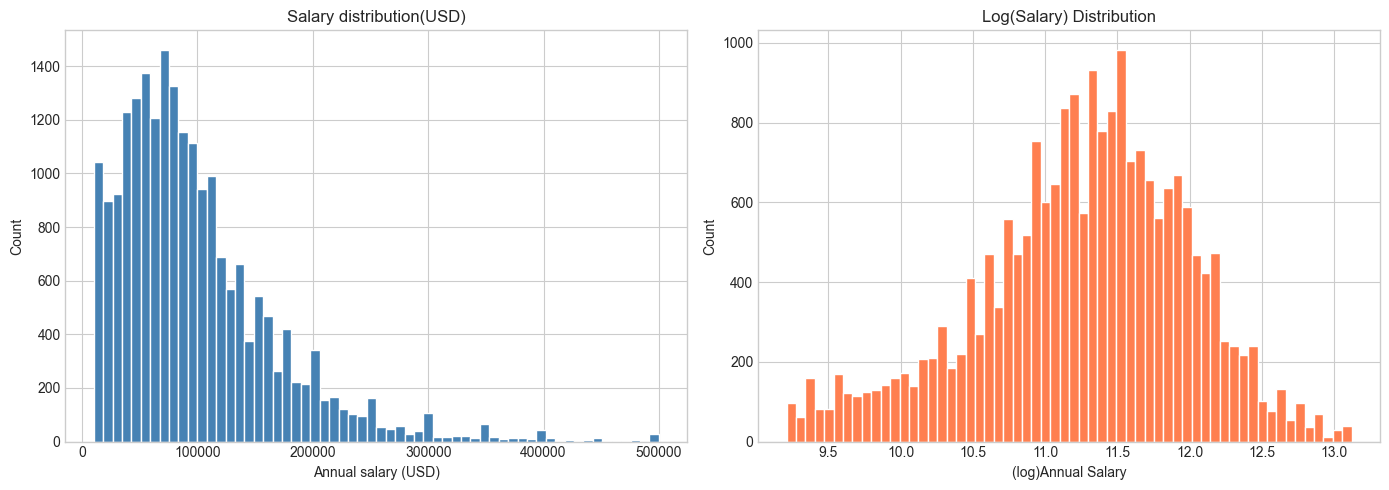

Median salary: $81,870
Mean Salary: $98,572


In [6]:
# Filtering - picking rows with salary between 10,000 and 500,000
salary_df =df[df[target_col].between(10000, 500000)]

#visualizations
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# raw distribution.
axes[0].hist(salary_df[target_col],bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary distribution(USD)')
axes[0].set_xlabel('Annual salary (USD)')
axes[0].set_ylabel('Count')

# log-scale distribution
axes[1].hist(np.log1p(salary_df[target_col]), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Salary) Distribution')
axes[1].set_xlabel('(log)Annual Salary')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/salary_distribution.png', dpi=300)
plt.show()

print(f'Median salary: ${salary_df[target_col].median():,.0f}')
print(f'Mean Salary: ${salary_df[target_col].mean():,.0f}')

In [7]:
features = ['Country','YearsCode', 'EdLevel', 'Employment', 'LanguagesHaveWorkedWith']

for col in features:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100
        unique_count = df[col].nunique() # nunique(r eturns the number of unique items (int) . unique returns the actual number of unique items
        print('Columns',col)
        print('Missing',missing_pct)
        print('unique values count: ', unique_count)
        print('First 5 rows: ')
        print(df[col].value_counts().head().to_string())
        print()

Columns Country
Missing 27.96039926002724
unique values count:  177
First 5 rows: 
Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409

Columns YearsCode
Missing 12.500254111524466
unique values count:  78
First 5 rows: 
YearsCode
10.0    3108
15.0    2540
20.0    2497
5.0     2267
8.0     2113

Columns EdLevel
Missing 2.118273667947389
unique values count:  8
First 5 rows: 
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20278
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12589
Some college/university study without earning a degree                                 6182
Secondary school (e.g. American high school, German Realschule or Gymnasium, 

C:\Users\hp\AppData\Local\Temp\ipykernel_25716\3187560285.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


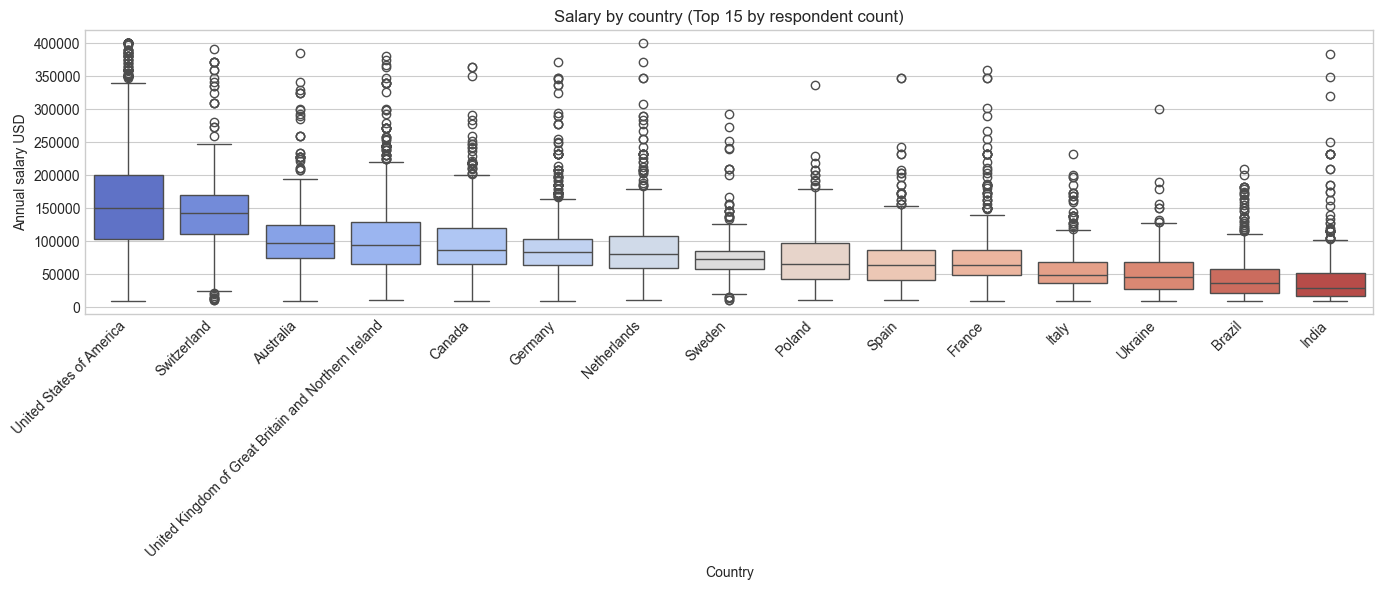

In [8]:
df_sal = df[df[target_col].between(10000, 400000)].copy()

top_countries =df_sal['Country'].value_counts().head(15).index
country_data = df_sal[df_sal['Country'].isin(top_countries)]

plt.figure(figsize=(14,6))
order = country_data.groupby('Country')[target_col].median().sort_values(ascending=False).index
sns.boxplot(
    data = country_data,
    x = 'Country', y=target_col,
    order = order,
    palette = 'coolwarm')
plt.xticks(rotation=45, ha= 'right')
plt.title('Salary by country (Top 15 by respondent count)')
plt.ylabel('Annual salary USD')
plt.tight_layout()
plt.savefig('../data/salary_by_country.png', dpi=300)
plt.show()

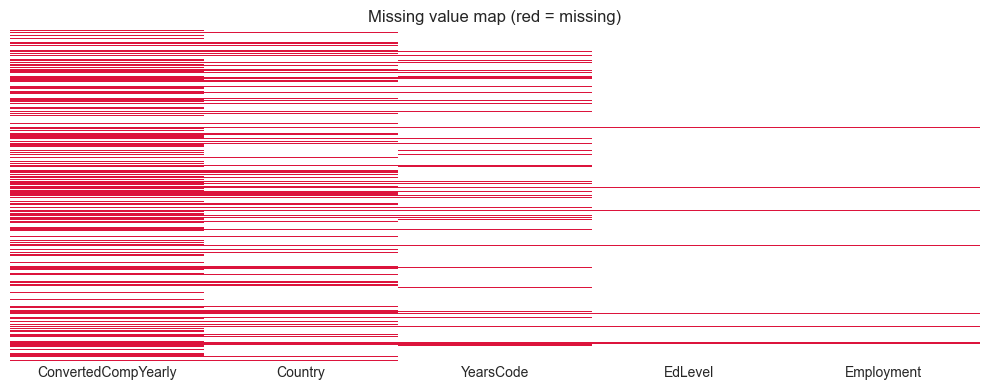

In [9]:
selected_cols = [target_col,'Country', 'YearsCode', 'EdLevel', 'Employment']
available_cols = [c for c in selected_cols if c in df.columns]

missing_df = df[available_cols].isna()
plt.figure(figsize=(10,4))
sns.heatmap(missing_df.sample(min(1000, len(df)), random_state=42), cbar=False, yticklabels=False, xticklabels=True, cmap=['white','crimson'])
plt.title('Missing value map (red = missing)')
plt.tight_layout()
plt.show()

In [10]:
df['EdLevel'].unique()

<ArrowStringArray>
[                                   'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                             'Some college/university study without earning a degree',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                                            'Other (please specify):',
                                                          'Primary/elementary school',
                                                                                  nan]
Length: 9, dtype: str

In [11]:
df['Employment'].unique()

<ArrowStringArray>
[                                            'Employed',
 'Independent contractor, freelancer, or self-employed',
                                              'Student',
                                              'Retired',
                                         'Not employed',
                                  'I prefer not to say',
                                                    nan]
Length: 7, dtype: str

In [12]:
df['LanguageHaveWorkedWith'].unique()

<ArrowStringArray>
[                                                                     'Bash/Shell (all shells);Dart;SQL',
                                                                                                  'Java',
                                                                   'Dart;HTML/CSS;JavaScript;TypeScript',
                                                                                       'Java;Kotlin;SQL',
 'C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;PowerShell;Python;SQL;TypeScript;VBA;Visual Basic (.Net)',
                                                                                            'Java;Scala',
                                                                                 'JavaScript;TypeScript',
                                     'Bash/Shell (all shells);HTML/CSS;JavaScript;Python;SQL;TypeScript',
                                                                                     'Java;Python;Scala',
                           

In [13]:
df['Country'].unique()

<ArrowStringArray>
[                 'Ukraine',              'Netherlands',
                    'India',                  'Georgia',
                'Australia',                   'Greece',
                  'Germany',               'Bangladesh',
                   'Brazil', 'United States of America',
 ...
                   'Gambia',                   'Malawi',
                    'Niger',                  'Lesotho',
               'San Marino',                 'Djibouti',
                  'Burundi',               'Cape Verde',
                    'Palau',                   'Guinea']
Length: 178, dtype: str

In [14]:
import sys
import os

sys.path.insert(0,os.path.dirname('../src/'))

from preprocess import  load_and_clean, get_feature_columns, TARGET

#This is going to load and clean the data
df = load_and_clean('../data/raw/results.csv')
df.to_csv('../data/cleaned/processed_data.csv', index=False)

This is the raw shape: (49191, 172)
Shape after salary filter: (21203, 172)
Selected 16 columns, expecting 6
Clean data Shape: (21203, 16)
Missing values per column: 
 Country                      0
YearsCode                   67
EdLevel                      0
Employment                   0
LanguageHaveWorkedWith    1359
DevType                      0
OrgSize                   2259
RemoteWork                   0
WorkExp                    248
Industry                   618
Age                          0
ICorPM                    2515
DatabaseHaveWorkedWith    4595
PlatformHaveWorkedWith    4951
ToolCountWork             3117
log_salary                   0 



# Changes to make so as to improve model r2
 
Originally -> 5 features, raw salary, OHE, basic XGBoost.
 
1. More features - We've added 10 features from raw data but are not processed.
2. log-transformed the salary column - now called, 'log_salary'.
3. Tune XGBoost params.n_estimators, max_depth, learning_rate, Regularization, 'reg_alpha' - L1 regularization (feature selection), 'reg_lambda' - L2 Regularization (weight shrinkage).
4. Target encoding - Country/ DevType/Industry.
5. Ordinal encoding - EdLevel/ RemoteWork / Age
6. Interaction features.

```Python
    def add_intercation_features(df):
        df['yearsCode_sq'] = df['YearsCode'] ** 2
        df['WorkExp_sq'] = df['WorkExp'] ** 2
        df['Exp_ratio'] = df['WorkExp']/ (df['YearsCode'] + 1)
        df['Tech_breadth'] = (df['LanguageCount'] + df['DatabaseCount'] + df['PlatformCount']).fillna(0)
        return df
```        

In [15]:
df['RemoteWork'].unique()

array([1, 2, 0])

In [ ]:
#pip install flask


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
df_cleaned = pd.read_csv('../data/cleaned/processed_data.csv')
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 21203 entries, 0 to 21202
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 21203 non-null  str    
 1   YearsCode               21136 non-null  float64
 2   EdLevel                 21021 non-null  float64
 3   Employment              21203 non-null  str    
 4   LanguageHaveWorkedWith  19844 non-null  float64
 5   DevType                 21203 non-null  str    
 6   OrgSize                 18944 non-null  str    
 7   RemoteWork              21203 non-null  int64  
 8   WorkExp                 20955 non-null  float64
 9   Industry                20585 non-null  str    
 10  Age                     21203 non-null  str    
 11  ICorPM                  18688 non-null  str    
 12  DatabaseHaveWorkedWith  16608 non-null  float64
 13  PlatformHaveWorkedWith  16252 non-null  float64
 14  ToolCountWork           18086 non-null  float64
 